In [ ]:
import cv2

image = cv2.imread(r"C:\Users\PC-LAB1\Desktop\shok\day 2 shapes (1).jpeg")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

area = cv2.contourArea(contours)
perimeter = cv2.arcLength(contours, True)
x, y, w, h = cv2.boundingRect(contours)

M = cv2.moments(contours)
if M["m00"] != 0:
    cx = int(M["m10"]/M["m00"])
    cy = int(M["m10"]/M["m00"])

aspect_ratio = w/h if h != 0 else 0
        



In [ ]:
import cv2

image = cv2.imread(r"C:\Users\PC-LAB1\Desktop\shok\day 2 shapes (1).jpeg")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

for i, contour in enumerate(contours):

    area = cv2.contourArea(contour)

    perimeter = cv2.arcLength(contour, True)

    x, y, w, h = cv2.boundingRect(contour)

    M = cv2.moments(contour)

    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        cx, cy = 0, 0

    aspect_ratio = w / h if h != 0 else 0

    print("Contour:", i + 1)
    print("Area:", area)
    print("Perimeter:", perimeter)
    print("Center:", (cx, cy))
    print("Width:", w)
    print("Height:", h)
    print("Aspect Ratio:", aspect_ratio)
    print()

result = image.copy()
cv2.drawContours(result, contours, -1, (0, 255, 0), 2)
cv2.imshow("result", result)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [25]:
import cv2
import numpy as np

image = cv2.imread(r"C:\Users\PC-LAB1\Desktop\shok\day 2 shapes (1).jpeg")

img = cv2.resize(image, (64, 64))

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

features = gray.flatten()

print("Number of features:", len(features))
print(features.tolist())
print(np.unique(features))

Number of features: 4096
[255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 252, 253, 253, 253, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 254, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 253, 253, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 254, 235, 85, 88, 93, 89, 94, 81, 240, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 254, 98, 32, 254, 254, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 25

In [28]:
import cv2
import numpy as np

image = cv2.imread(r"C:\Users\PC-LAB1\Desktop\shok\lena5.jpg")

img = cv2.resize(image, (64, 64))

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

hist = cv2.calcHist(
    [img],
    [0],
    None,
    [32],
    [0, 256]
)

features = hist.flatten()

print("Number of features:", len(features))
print("Full list:")
print(features.tolist())
print("unique featuers:")
print(np.unique(features))

Number of features: 32
Full list:
[0.0, 0.0, 1.0, 6.0, 12.0, 26.0, 64.0, 184.0, 421.0, 378.0, 417.0, 330.0, 369.0, 327.0, 304.0, 284.0, 255.0, 104.0, 131.0, 154.0, 99.0, 83.0, 58.0, 56.0, 20.0, 11.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0]
unique featuers:
[  0.   1.   2.   6.  11.  12.  20.  26.  56.  58.  64.  83.  99. 104.
 131. 154. 184. 255. 284. 304. 327. 330. 369. 378. 417. 421.]


In [57]:
import cv2
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# ============================================================
# SETTINGS
# ============================================================

DATA_FOLDER = r"C:\Users\PC-LAB1\Desktop\shok\pictures\train"

IMAGES_PER_CLASS = 2000


# ============================================================
# FEATURE EXTRACTION
# ============================================================

def extract_features(image_path):

    img = cv2.imread(image_path)

    if img is None:
        return None

    # Resize
    img = cv2.resize(img, (64, 64))


    # ========================================================
    # 1. COLOR HISTOGRAM FEATURES
    # 32 bins × 3 channels = 96 features
    # ========================================================

    hist_features = []

    for channel in range(3):

        hist = cv2.calcHist(
            [img],
            [channel],
            None,
            [32],
            [0, 256]
        )

        hist = cv2.normalize(hist, hist).flatten()

        hist_features.extend(hist)

    hist_features = np.array(hist_features)


    # ========================================================
    # 2. STATISTICAL FEATURES
    # Mean + standard deviation for each channel = 6
    # ========================================================

    stats = []

    for channel in range(3):

        channel_data = img[:, :, channel]

        stats.append(np.mean(channel_data))
        stats.append(np.std(channel_data))

    stats = np.array(stats)


    # ========================================================
    # 3. EDGE FEATURES
    # ========================================================

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 100, 200)

    edge_features = np.array([
        np.mean(edges > 0),
        np.std(edges),
        np.sum(edges > 0)
    ])


    # ========================================================
    # 4. COMBINE FEATURES
    # ========================================================

    features = np.concatenate([
        hist_features,
        stats,
        edge_features
    ])

    return features


# ============================================================
# FIND CAT AND DOG FILES
# ============================================================

files = sorted(os.listdir(DATA_FOLDER))

cat_files = [
    f for f in files
    if f.lower().startswith("cat")
    and f.lower().endswith((".jpg", ".jpeg", ".png"))
]

dog_files = [
    f for f in files
    if f.lower().startswith("dog")
    and f.lower().endswith((".jpg", ".jpeg", ".png"))
]


# ============================================================
# TAKE 4000 CATS + 4000 DOGS
# ============================================================

cat_files = cat_files[:IMAGES_PER_CLASS]
dog_files = dog_files[:IMAGES_PER_CLASS]

selected_files = cat_files + dog_files


print("Selected cats:", len(cat_files))
print("Selected dogs:", len(dog_files))


# ============================================================
# EXTRACT FEATURES
# ============================================================

X = []
y = []

for filename in selected_files:

    path = os.path.join(DATA_FOLDER, filename)

    features = extract_features(path)

    if features is None:
        continue

    X.append(features)

    if filename.lower().startswith("cat"):
        y.append(0)

    elif filename.lower().startswith("dog"):
        y.append(1)


X = np.array(X)
y = np.array(y)


# ============================================================
# DATASET INFORMATION
# ============================================================

print("\nDataset information")
print("-------------------")
print("Number of images:", len(X))
print("Feature vector size:", X.shape[1])
print("Cats:", np.sum(y == 0))
print("Dogs:", np.sum(y == 1))


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("\nTrain/Test split")
print("----------------")
print("Training images:", len(X_train))
print("Testing images:", len(X_test))


# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# ============================================================
# ANN / MLP
# ============================================================

clf = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=300,
    random_state=42
)


# ============================================================
# TRAIN
# ============================================================

clf.fit(X_train, y_train)


print("\nTraining information")
print("--------------------")
print("Iterations:", clf.n_iter_)


# ============================================================
# PREDICT
# ============================================================

y_pred = clf.predict(X_test)


# ============================================================
# EVALUATION
# ============================================================

print("\nAccuracy")
print("--------")
print(accuracy_score(y_test, y_pred))


print("\nConfusion Matrix")
print("----------------")
print(confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
))


print("\nClassification Report")
print("---------------------")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Cat", "Dog"]
))

Selected cats: 2000
Selected dogs: 2000

Dataset information
-------------------
Number of images: 4000
Feature vector size: 105
Cats: 2000
Dogs: 2000

Train/Test split
----------------
Training images: 3200
Testing images: 800

Training information
--------------------
Iterations: 263

Accuracy
--------
0.575

Confusion Matrix
----------------
[[228 172]
 [168 232]]

Classification Report
---------------------
              precision    recall  f1-score   support

         Cat       0.58      0.57      0.57       400
         Dog       0.57      0.58      0.58       400

    accuracy                           0.57       800
   macro avg       0.58      0.57      0.57       800
weighted avg       0.58      0.57      0.57       800



In [4]:
import cv2
import numpy as np
import os

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# ============================================================
# SETTINGS
# ============================================================

DATA_FOLDER = r"C:\Users\PC-LAB1\Desktop\shok\pictures\train"

IMAGES_PER_CLASS = 4000


# ============================================================
# FEATURE EXTRACTION
# ============================================================

def extract_features(image_path):

    img = cv2.imread(image_path)

    if img is None:
        return None

    # Resize
    img = cv2.resize(img, (64, 64))


    # ========================================================
    # 1. HSV COLOR HISTOGRAM
    # 96 FEATURES
    # ========================================================

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    hist_features = []

    for channel in range(3):

        if channel == 0:
            hist_range = [0, 180]
        else:
            hist_range = [0, 256]

        hist = cv2.calcHist(
            [hsv],
            [channel],
            None,
            [32],
            hist_range
        )

        hist = cv2.normalize(hist, hist).flatten()

        hist_features.extend(hist)

    hist_features = np.array(hist_features)


    # ========================================================
    # 2. STATISTICAL FEATURES
    # 15 FEATURES
    # ========================================================

    stats = []

    for channel in range(3):

        channel_data = hsv[:, :, channel]

        stats.append(np.mean(channel_data))
        stats.append(np.std(channel_data))
        stats.append(np.min(channel_data))
        stats.append(np.max(channel_data))
        stats.append(np.median(channel_data))

    stats = np.array(stats)


    # ========================================================
    # 3. EDGE FEATURES
    # 3 FEATURES
    # ========================================================

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 100, 200)

    edge_features = np.array([
        np.mean(edges > 0),
        np.std(edges),
        np.sum(edges > 0)
    ])


    # ========================================================
    # 4. HUE MOMENTS
    # 4 FEATURES
    # ========================================================

    hue = hsv[:, :, 0].astype(np.float32)

    hue_mean = np.mean(hue)

    hue_std = np.std(hue)

    hue_centered = hue - hue_mean

    hue_skewness = np.mean(
        hue_centered ** 3
    ) / (hue_std ** 3 + 1e-8)

    hue_kurtosis = np.mean(
        hue_centered ** 4
    ) / (hue_std ** 4 + 1e-8)

    hue_features = np.array([
        hue_mean,
        hue_std,
        hue_skewness,
        hue_kurtosis
    ])


    # ========================================================
    # 5. HOG FEATURES
    # 1764 FEATURES
    # ========================================================

    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )


    # ========================================================
    # 6. COMBINE ALL FEATURES
    # ========================================================

    features = np.concatenate([
        hist_features,
        stats,
        edge_features,
        hue_features,
        hog_features
    ])

    return features


# ============================================================
# FIND CAT AND DOG FILES
# ============================================================

files = sorted(os.listdir(DATA_FOLDER))

cat_files = [
    f for f in files
    if f.lower().startswith("cat")
    and f.lower().endswith((".jpg", ".jpeg", ".png"))
]

dog_files = [
    f for f in files
    if f.lower().startswith("dog")
    and f.lower().endswith((".jpg", ".jpeg", ".png"))
]


# ============================================================
# TAKE 4000 CATS + 4000 DOGS
# ============================================================

cat_files = cat_files[:IMAGES_PER_CLASS]

dog_files = dog_files[:IMAGES_PER_CLASS]

selected_files = cat_files + dog_files


print("Selected cats:", len(cat_files))
print("Selected dogs:", len(dog_files))


# ============================================================
# EXTRACT FEATURES
# ============================================================

X = []
y = []

for filename in selected_files:

    path = os.path.join(
        DATA_FOLDER,
        filename
    )

    features = extract_features(path)

    if features is None:
        continue

    X.append(features)

    if filename.lower().startswith("cat"):
        y.append(0)

    elif filename.lower().startswith("dog"):
        y.append(1)


X = np.array(X)

y = np.array(y)


# ============================================================
# DATASET INFORMATION
# ============================================================

print("\nDataset information")
print("-------------------")

print("Number of images:", len(X))

print("Feature vector size:", X.shape[1])

print("Cats:", np.sum(y == 0))

print("Dogs:", np.sum(y == 1))


# ============================================================
# FEATURE VECTOR INFORMATION
# ============================================================

print("\nFeature vector information")
print("--------------------------")

print("Number of features:", len(X[0]))

print("First 20 features:", X[0][:20])


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("\nTrain/Test split")
print("----------------")

print("Training images:", len(X_train))

print("Testing images:", len(X_test))


# ============================================================
# STANDARD SCALER
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# ============================================================
# MLP
# ============================================================

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    max_iter=50,
    random_state=42
)


# ============================================================
# TRAIN
# ============================================================

mlp.fit(
    X_train,
    y_train
)


# ============================================================
# TRAINING INFORMATION
# ============================================================

print("\nTraining information")
print("--------------------")

print("Iterations:", mlp.n_iter_)


# ============================================================
# PREDICT
# ============================================================

y_pred = mlp.predict(
    X_test
)


# ============================================================
# EVALUATION
# ============================================================

print("\nAccuracy")
print("--------")

print(
    accuracy_score(
        y_test,
        y_pred
    )
)


print("\nConfusion Matrix")
print("----------------")

print(
    confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )
)


print("\nClassification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=["Cat", "Dog"]
    )
)

Selected cats: 4000
Selected dogs: 4000

Dataset information
-------------------
Number of images: 8000
Feature vector size: 1882
Cats: 4000
Dogs: 4000

Feature vector information
--------------------------
Number of features: 1882
First 20 features: [3.12163174e-04 3.74595821e-03 1.18622005e-01 9.81441021e-01
 1.49838328e-01 1.15500372e-02 9.98922158e-03 1.56081584e-03
 9.36489552e-04 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 3.12163174e-04 0.00000000e+00 0.00000000e+00
 0.00000000e+00 3.12163174e-04 0.00000000e+00 0.00000000e+00]

Train/Test split
----------------
Training images: 6400
Testing images: 1600

Training information
--------------------
Iterations: 30

Accuracy
--------
0.7775

Confusion Matrix
----------------
[[602 198]
 [158 642]]

Classification Report
---------------------
              precision    recall  f1-score   support

         Cat       0.79      0.75      0.77       800
         Dog       0.76      0.80      0.78       800

    accuracy  

In [65]:
# ============================================================
# TEST ONE IMAGE
# ============================================================

TEST_IMAGE = r"C:\Users\PC-LAB1\Desktop\shok\pictures\test1\test1\3.jpg"

features = extract_features(TEST_IMAGE)

features = features.reshape(1, -1)

prediction = clf.predict(features)[0]

if prediction == 0:
    print("Prediction: Cat")
else:
    print("Prediction: Dog")

Prediction: Dog


In [21]:
import cv2
import numpy as np
import os

from skimage.feature import hog, local_binary_pattern

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# ============================================================
# SETTINGS
# ============================================================

DATA_FOLDER = r"C:\Users\PC-LAB1\Desktop\shok\pictures\train"

IMAGES_PER_CLASS = 4000


# ============================================================
# FEATURE EXTRACTION
# ============================================================

def extract_features(image_path):

    img = cv2.imread(image_path)

    if img is None:
        return None

    # Resize
    img = cv2.resize(img, (64, 64))


    # ========================================================
    # 1. HSV COLOR HISTOGRAM
    # 96 FEATURES
    # ========================================================

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    hist_features = []

    for channel in range(3):

        if channel == 0:
            hist_range = [0, 180]
        else:
            hist_range = [0, 256]

        hist = cv2.calcHist(
            [hsv],
            [channel],
            None,
            [32],
            hist_range
        )

        hist = cv2.normalize(
            hist,
            hist
        ).flatten()

        hist_features.extend(hist)

    hist_features = np.array(hist_features)


    # ========================================================
    # 2. STATISTICAL FEATURES
    # 15 FEATURES
    # ========================================================

    stats = []

    for channel in range(3):

        channel_data = hsv[:, :, channel]

        stats.append(np.mean(channel_data))
        stats.append(np.std(channel_data))
        stats.append(np.min(channel_data))
        stats.append(np.max(channel_data))
        stats.append(np.median(channel_data))

    stats = np.array(stats)


    # ========================================================
    # 3. EDGE FEATURES
    # 3 FEATURES
    # ========================================================

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    edges = cv2.Canny(
        gray,
        100,
        200
    )

    edge_features = np.array([
        np.mean(edges > 0),
        np.std(edges),
        np.sum(edges > 0)
    ])


    # ========================================================
    # 4. HUE MOMENTS
    # 4 FEATURES
    # ========================================================

    hue = hsv[:, :, 0].astype(
        np.float32
    )

    hue_mean = np.mean(hue)

    hue_std = np.std(hue)

    hue_centered = hue - hue_mean

    hue_skewness = (
        np.mean(hue_centered ** 3)
        /
        (hue_std ** 3 + 1e-8)
    )

    hue_kurtosis = (
        np.mean(hue_centered ** 4)
        /
        (hue_std ** 4 + 1e-8)
    )

    hue_features = np.array([
        hue_mean,
        hue_std,
        hue_skewness,
        hue_kurtosis
    ])


    # ========================================================
    # 5. HOG FEATURES
    # 1764 FEATURES
    # ========================================================

    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )


    # ========================================================
    # 6. LBP TEXTURE FEATURES
    # ========================================================

    lbp = local_binary_pattern(
        gray,
        P=8,
        R=1,
        method="uniform"
    )

    lbp_hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, 11),
        range=(0, 10)
    )

    lbp_hist = lbp_hist.astype(
        np.float32
    )

    lbp_hist /= (
        np.sum(lbp_hist) + 1e-8
    )


    # ========================================================
    # 7. COMBINE ALL FEATURES
    # ========================================================

    features = np.concatenate([
        hist_features,
        stats,
        edge_features,
        hue_features,
        hog_features,
        lbp_hist
    ])

    return features


# ============================================================
# FIND CAT AND DOG FILES
# ============================================================

files = sorted(
    os.listdir(DATA_FOLDER)
)

cat_files = [
    f for f in files
    if f.lower().startswith("cat")
    and f.lower().endswith(
        (".jpg", ".jpeg", ".png")
    )
]

dog_files = [
    f for f in files
    if f.lower().startswith("dog")
    and f.lower().endswith(
        (".jpg", ".jpeg", ".png")
    )
]


# ============================================================
# TAKE 4000 CATS + 4000 DOGS
# ============================================================

cat_files = cat_files[
    :IMAGES_PER_CLASS
]

dog_files = dog_files[
    :IMAGES_PER_CLASS
]

selected_files = (
    cat_files +
    dog_files
)


print(
    "Selected cats:",
    len(cat_files)
)

print(
    "Selected dogs:",
    len(dog_files)
)


# ============================================================
# EXTRACT FEATURES
# ============================================================

X = []
y = []

for filename in selected_files:

    path = os.path.join(
        DATA_FOLDER,
        filename
    )

    features = extract_features(
        path
    )

    if features is None:
        continue

    X.append(features)

    if filename.lower().startswith(
        "cat"
    ):
        y.append(0)

    elif filename.lower().startswith(
        "dog"
    ):
        y.append(1)


X = np.array(X)

y = np.array(y)


# ============================================================
# DATASET INFORMATION
# ============================================================

print("\nDataset information")
print("-------------------")

print(
    "Number of images:",
    len(X)
)

print(
    "Feature vector size:",
    X.shape[1]
)

print(
    "Cats:",
    np.sum(y == 0)
)

print(
    "Dogs:",
    np.sum(y == 1)
)


# ============================================================
# FEATURE VECTOR INFORMATION
# ============================================================

print(
    "\nFeature vector information"
)

print(
    "--------------------------"
)

print(
    "Number of features:",
    len(X[0])
)

print(
    "First 20 features:",
    X[0][:20]
)


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("\nTrain/Test split")
print("----------------")

print(
    "Training images:",
    len(X_train)
)

print(
    "Testing images:",
    len(X_test)
)


# ============================================================
# STANDARD SCALER
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)


# ============================================================
# SVM
# ============================================================

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)


# ============================================================
# TRAIN
# ============================================================

svm.fit(
    X_train,
    y_train
)


# ============================================================
# PREDICT
# ============================================================

y_pred = svm.predict(
    X_test
)


# ============================================================
# EVALUATION
# ============================================================

print("\nAccuracy")
print("--------")

print(
    accuracy_score(
        y_test,
        y_pred
    )
)


print("\nConfusion Matrix")
print("----------------")

print(
    confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )
)


print("\nClassification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=[
            "Cat",
            "Dog"
        ]
    )
)

Selected cats: 4000
Selected dogs: 4000

Dataset information
-------------------
Number of images: 8000
Feature vector size: 1892
Cats: 4000
Dogs: 4000

Feature vector information
--------------------------
Number of features: 1892
First 20 features: [3.12163174e-04 3.74595821e-03 1.18622005e-01 9.81441021e-01
 1.49838328e-01 1.15500372e-02 9.98922158e-03 1.56081584e-03
 9.36489552e-04 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 3.12163174e-04 0.00000000e+00 0.00000000e+00
 0.00000000e+00 3.12163174e-04 0.00000000e+00 0.00000000e+00]

Train/Test split
----------------
Training images: 6400
Testing images: 1600

Accuracy
--------
0.795625

Confusion Matrix
----------------
[[627 173]
 [154 646]]

Classification Report
---------------------
              precision    recall  f1-score   support

         Cat       0.80      0.78      0.79       800
         Dog       0.79      0.81      0.80       800

    accuracy                           0.80      1600
   macro avg    

Prediction: Cat


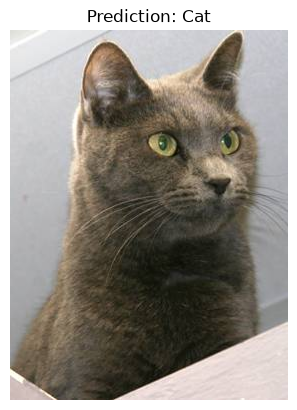

In [22]:
import cv2
import matplotlib.pyplot as plt

IMAGE_PATH = r"C:\Users\PC-LAB1\Desktop\shok\pictures\test1\test1\11.jpg"

features = extract_features(IMAGE_PATH)

features_scaled = scaler.transform(features.reshape(1, -1))

prediction = svm.predict(features_scaled)[0]

label = "Cat" if prediction == 0 else "Dog"

print("Prediction:", label)

img = cv2.imread(IMAGE_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Prediction: " + label)
plt.axis("off")
plt.show()

In [21]:
import cv2
import numpy as np
import os

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# ============================================================
# SETTINGS
# ============================================================

DATA_FOLDER = r"C:\Users\PC-LAB1\Desktop\shok\pictures\train"

IMAGES_PER_CLASS = 4000


# ============================================================
# FEATURE EXTRACTION
# ============================================================

def extract_features(image_path):

    img = cv2.imread(image_path)

    if img is None:
        return None

    # Resize
    img = cv2.resize(img, (64, 64))


    # ========================================================
    # 1. HSV COLOR HISTOGRAM
    # 96 FEATURES
    # ========================================================

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    hist_features = []

    for channel in range(3):

        if channel == 0:
            hist_range = [0, 180]
        else:
            hist_range = [0, 256]

        hist = cv2.calcHist(
            [hsv],
            [channel],
            None,
            [32],
            hist_range
        )

        hist = cv2.normalize(hist, hist).flatten()

        hist_features.extend(hist)

    hist_features = np.array(hist_features)


    # ========================================================
    # 2. STATISTICAL FEATURES
    # MEAN + STD + MIN + MAX + MEDIAN
    # 15 FEATURES
    # ========================================================

    stats = []

    for channel in range(3):

        channel_data = hsv[:, :, channel]

        stats.append(np.mean(channel_data))
        stats.append(np.std(channel_data))
        stats.append(np.min(channel_data))
        stats.append(np.max(channel_data))
        stats.append(np.median(channel_data))

    stats = np.array(stats)


    # ========================================================
    # 3. EDGE FEATURES
    # 3 FEATURES
    # ========================================================

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 100, 200)

    edge_features = np.array([
        np.mean(edges > 0),
        np.std(edges),
        np.sum(edges > 0)
    ])


    # ========================================================
    # 4. HUE MOMENTS
    # 4 FEATURES
    # ========================================================

    hue = hsv[:, :, 0].astype(np.float32)

    hue_mean = np.mean(hue)

    hue_std = np.std(hue)

    hue_centered = hue - hue_mean

    hue_skewness = np.mean(
        hue_centered ** 3
    ) / (hue_std ** 3 + 1e-8)

    hue_kurtosis = np.mean(
        hue_centered ** 4
    ) / (hue_std ** 4 + 1e-8)

    hue_features = np.array([
        hue_mean,
        hue_std,
        hue_skewness,
        hue_kurtosis
    ])


    # ========================================================
    # 5. HOG FEATURES
    # 1764 FEATURES
    # ========================================================

    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )


    # ========================================================
    # 6. COMBINE ALL FEATURES
    # ========================================================

    features = np.concatenate([
        hist_features,
        stats,
        edge_features,
        hue_features,
        hog_features
    ])

    return features


# ============================================================
# FIND CAT AND DOG FILES
# ============================================================

files = sorted(os.listdir(DATA_FOLDER))

cat_files = [
    f for f in files
    if f.lower().startswith("cat")
    and f.lower().endswith((".jpg", ".jpeg", ".png"))
]

dog_files = [
    f for f in files
    if f.lower().startswith("dog")
    and f.lower().endswith((".jpg", ".jpeg", ".png"))
]


# ============================================================
# TAKE 4000 CATS + 4000 DOGS
# ============================================================

cat_files = cat_files[:IMAGES_PER_CLASS]

dog_files = dog_files[:IMAGES_PER_CLASS]

selected_files = cat_files + dog_files


print("Selected cats:", len(cat_files))
print("Selected dogs:", len(dog_files))


# ============================================================
# EXTRACT FEATURES
# ============================================================

X = []
y = []

for filename in selected_files:

    path = os.path.join(
        DATA_FOLDER,
        filename
    )

    features = extract_features(path)

    if features is None:
        continue

    X.append(features)

    if filename.lower().startswith("cat"):
        y.append(0)

    elif filename.lower().startswith("dog"):
        y.append(1)


X = np.array(X)

y = np.array(y)


# ============================================================
# DATASET INFORMATION
# ============================================================

print("\nDataset information")
print("-------------------")

print("Number of images:", len(X))

print("Feature vector size:", X.shape[1])

print("Cats:", np.sum(y == 0))

print("Dogs:", np.sum(y == 1))


# ============================================================
# FEATURE VECTOR INFORMATION
# ============================================================

print("\nFeature vector information")
print("--------------------------")

print("Number of features:", len(X[0]))

print("First 20 features:", X[0][:20])


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("\nTrain/Test split")
print("----------------")

print("Training images:", len(X_train))

print("Testing images:", len(X_test))


# ============================================================
# STANDARD SCALER
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# ============================================================
# SVM
# ============================================================

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)


# ============================================================
# TRAIN
# ============================================================

svm.fit(
    X_train,
    y_train
)


# ============================================================
# PREDICT
# ============================================================

y_pred = svm.predict(
    X_test
)


# ============================================================
# EVALUATION
# ============================================================

print("\nAccuracy")
print("--------")

print(
    accuracy_score(
        y_test,
        y_pred
    )
)


print("\nConfusion Matrix")
print("----------------")

print(
    confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )
)


print("\nClassification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=["Cat", "Dog"]
    )
)

Selected cats: 4000
Selected dogs: 4000

Dataset information
-------------------
Number of images: 8000
Feature vector size: 1882
Cats: 4000
Dogs: 4000

Feature vector information
--------------------------
Number of features: 1882
First 20 features: [3.12163174e-04 3.74595821e-03 1.18622005e-01 9.81441021e-01
 1.49838328e-01 1.15500372e-02 9.98922158e-03 1.56081584e-03
 9.36489552e-04 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 3.12163174e-04 0.00000000e+00 0.00000000e+00
 0.00000000e+00 3.12163174e-04 0.00000000e+00 0.00000000e+00]

Train/Test split
----------------
Training images: 6400
Testing images: 1600

Accuracy
--------
0.795625

Confusion Matrix
----------------
[[626 174]
 [153 647]]

Classification Report
---------------------
              precision    recall  f1-score   support

         Cat       0.80      0.78      0.79       800
         Dog       0.79      0.81      0.80       800

    accuracy                           0.80      1600
   macro avg    

Number of images: 60000


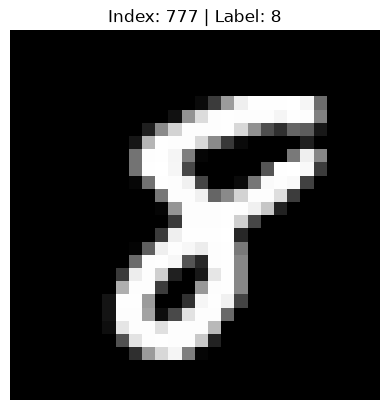

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV
path = r"C:\Users\PC-LAB1\Desktop\shok\mnist\mnist_train.csv"

df = pd.read_csv(path)

# Choose image index
index = 777

# Number of images
print("Number of images:", len(df))

# Get label
label = df.iloc[index, 0]

# Get image pixels
image = df.iloc[index, 1:].values.reshape(28, 28)

# Display image
plt.imshow(image, cmap="gray")
plt.title(f"Index: {index} | Label: {label}")
plt.axis("off")
plt.show()